# Case Study: Actinoform Clouds

In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

## Download Data 

In [9]:
auth = earthaccess.login(persist=True)

In [10]:
# results = earthaccess.search_datasets(instrument="oci")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [13]:
results = earthaccess.search_data(
    short_name= "PACE_HARP2_L2_CLOUD_GPC", 
    # temporal= ("2025-07-01", "2025-07-31"),
    temporal= ("2024-07-14T20:20:00", "2024-07-14T21:40:00"),
    count=1
)
print(len(results))

In [15]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

## Load Dataset

In [2]:
# import h5py

# def print_hdf5_structure(file_path):
#     with h5py.File(file_path, 'r') as f:
#         def print_attrs(name, obj):
#             if isinstance(obj, h5py.Group):
#                 print(f"Group: {name}")
#             elif isinstance(obj, h5py.Dataset):
#                 print(f"  Dataset: {name}")
#         f.visititems(print_attrs)

# print_hdf5_structure('PACE_OCI.20240714T201640.L2.CLD.V3_1.nc')

In [2]:
path_OCI = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1/PACE_OCI.20240714T201640.L2.CLD.V3_1.nc"
ds_OCI = xr.open_dataset(path_OCI, group='geophysical_data')
nav_OCI = xr.open_dataset(path_OCI, group='navigation_data')

In [3]:
path_HARP2 = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20240714T201640.L2.CLOUD_GPC.V3_0.nc"
ds_HARP2 = xr.open_dataset(path_HARP2, group='geophysical_data')
geo_HARP2 = xr.open_dataset(path_HARP2, group='geolocation_data')

In [4]:
# Select variable
OCI_CER = ds_OCI['cer_21'].values
lon = nav_OCI['longitude']
lat = nav_OCI['latitude']

In [5]:
# Select variable
HARP2_CER = ds_HARP2['cloud_bow_droplet_effective_radius'].values
lon_h = geo_HARP2['longitude']
lat_h = geo_HARP2['latitude']

In [6]:
y0,x0 = 26,267
y1,x1 = 289,269 

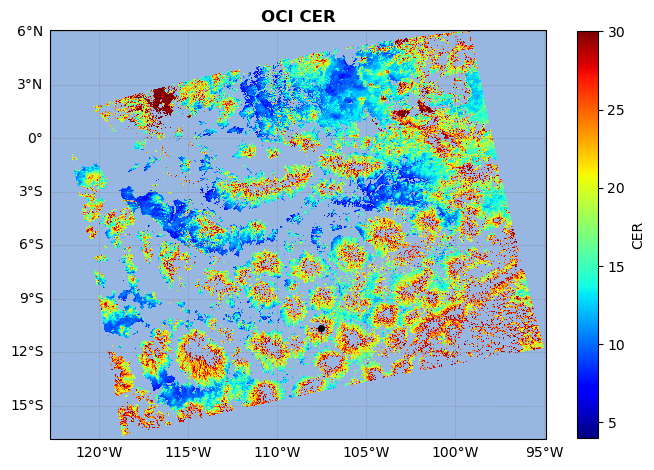

In [10]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon, lat, OCI_CER, vmin=4, vmax=30, cmap='jet', shading='auto')

ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='k', markersize=4, transform=ccrs.PlateCarree())
# print(f'CER of pixel: {OCI_CER[y0,x0]:.2f} μm')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('OCI CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.88, pad=0.05)
cbar.set_label('CER')

# plt.savefig("OCI.png", dpi=500, bbox_inches="tight")
plt.show()

CER of pixel: 52.51 μm


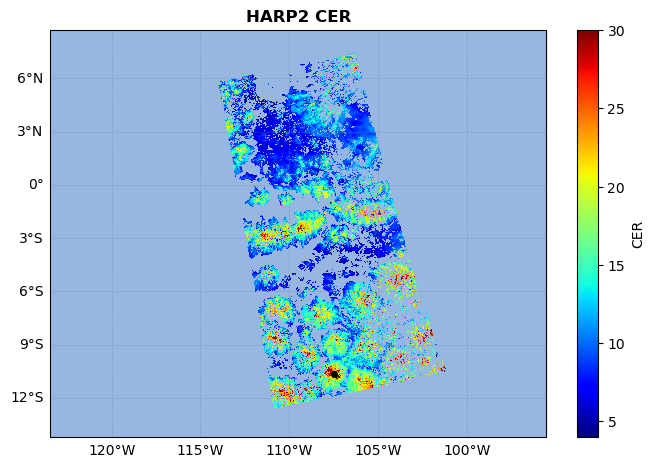

In [11]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon_h, lat_h, HARP2_CER, vmin=4, vmax=30, cmap='jet', shading='auto')

ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='k', markersize=4, transform=ccrs.PlateCarree())
print(f'CER of pixel: {HARP2_CER[y0,x0]:.2f} μm')

# ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='o', color='w', markersize=4, transform=ccrs.PlateCarree())
# print(f'CER of pixel: {HARP2_CER[y1,x1]:.2f} μm')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.88, pad=0.05)
cbar.set_label('CER')

# plt.savefig("HARP2.png", dpi=500, bbox_inches="tight")
plt.show()

CEV of pixel: 0.01


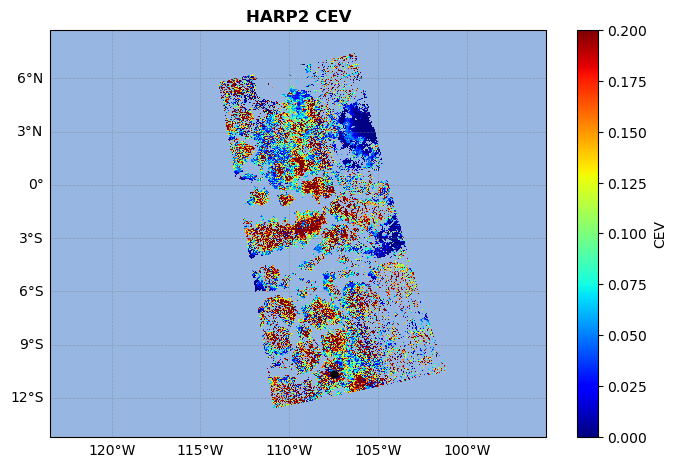

In [12]:
HARP2_CEV = ds_HARP2['cloud_bow_droplet_effective_variance']

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon_h, lat_h, HARP2_CEV, vmin=0, vmax=0.2, cmap='jet', shading='auto')

ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='k', markersize=5, transform=ccrs.PlateCarree())
print(f'CEV of pixel: {HARP2_CEV[y0,x0]:.2f}')

# ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='o', color='w', markersize=5, transform=ccrs.PlateCarree())
# print(f'CEV of pixel: {HARP2_CEV[y1,x1]:.2f}')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CEV', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.88, pad=0.05)
cbar.set_label('CEV')

plt.show()

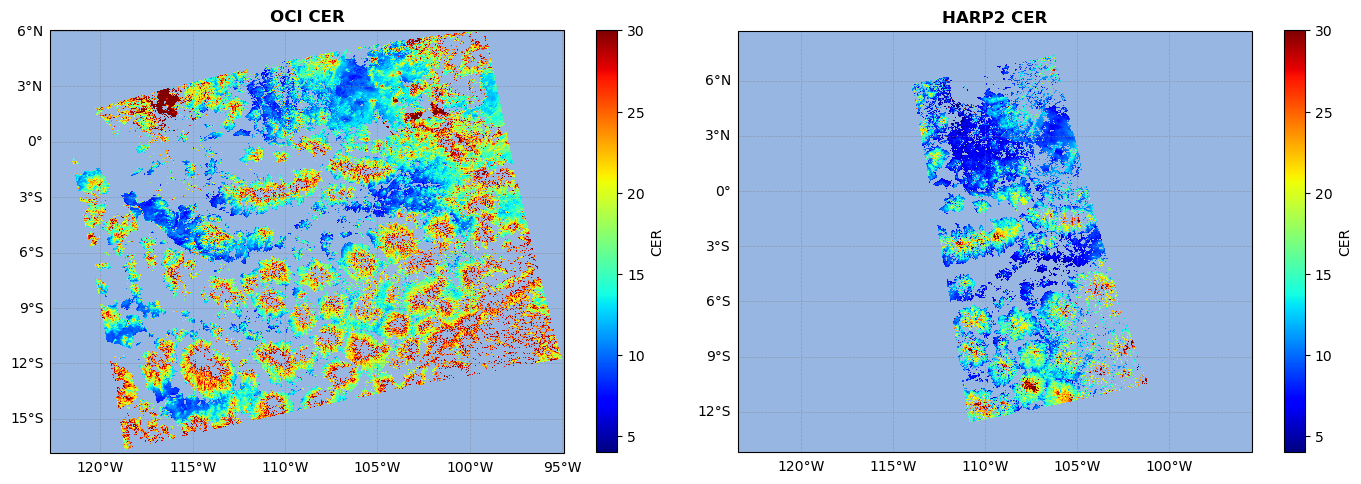

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot: OCI CER 
im1 = axes[0].pcolormesh(lon, lat, OCI_CER, vmin=4, vmax=30, cmap='jet', shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
axes[0].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[0].add_feature(cfeature.OCEAN)
axes[0].set_title('OCI CER', fontsize=12, fontweight='bold')

gl = axes[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                       color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', shrink=0.63, pad=0.05)
cbar1.set_label('CER')

# Second subplot: HARP2 CER
im2 = axes[1].pcolormesh(lon_h, lat_h, HARP2_CER, vmin=4, vmax=30, cmap='jet', shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
axes[1].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[1].add_feature(cfeature.OCEAN)
axes[1].set_title('HARP2 CER', fontsize=12, fontweight='bold')

gl = axes[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                       color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar2 = plt.colorbar(im2, ax=axes[1], orientation='vertical', shrink=0.63, pad=0.05)
cbar2.set_label('CER')

plt.tight_layout()
# plt.savefig("OCI_HARP2.png", dpi=500, bbox_inches="tight")
plt.show()

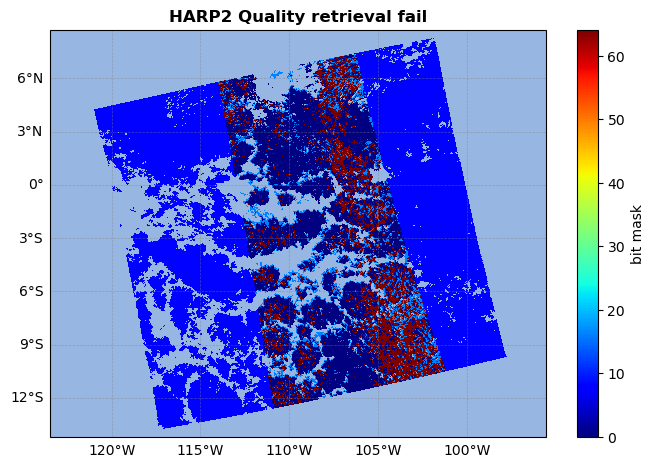

In [16]:
data = ds_HARP2['cloud_bow_quality_retrieval_fail']   # bit= 0 means retrieval is ok, bit >0 means failed bits

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon_h, lat_h, data, cmap='jet', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 Quality retrieval fail', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.88, pad=0.05)
cbar.set_label('bit mask')

# plt.savefig("HARP2 Quality retrieval fail", dpi=500, bbox_inches="tight")
plt.show()